In [26]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [27]:
# ============================================================
# CELL 2: DATASET PATHS
# ============================================================

TRAIN_PATH = Path(
    r"C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\data\train.csv"
)

TEST_PATH = Path(
    r"C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\data\test.csv"
)

print("Training path:")
print(TRAIN_PATH)

print("\nTest path:")
print(TEST_PATH)

Training path:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\data\train.csv

Test path:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\data\test.csv


In [28]:
# ============================================================
# CELL 3: VERIFY DATASET FILES
# ============================================================

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"Training file not found:\n{TRAIN_PATH}"
    )

if not TEST_PATH.exists():
    raise FileNotFoundError(
        f"Test file not found:\n{TEST_PATH}"
    )

print("✓ train.csv found")
print("✓ test.csv found")

✓ train.csv found
✓ test.csv found


In [29]:
# ============================================================
# CELL 4: LOAD TRAINING DATA
# ============================================================

df_raw = pd.read_csv(TRAIN_PATH)

# Only normalize column names.
# No question preprocessing is performed here.
df_raw.columns = (
    df_raw.columns
    .astype(str)
    .str.strip()
)

print("Training dataset loaded successfully.")
print()

print("Rows    :", f"{len(df_raw):,}")
print("Columns :", len(df_raw.columns))

print("\nColumns:")
print(list(df_raw.columns))

Training dataset loaded successfully.

Rows    : 404,290
Columns : 6

Columns:
['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']


In [30]:
# ============================================================
# CELL 5: LOAD KAGGLE TEST DATA
# ============================================================

df_kaggle_test = pd.read_csv(TEST_PATH)

df_kaggle_test.columns = (
    df_kaggle_test.columns
    .astype(str)
    .str.strip()
)

print("Kaggle test dataset loaded successfully.")
print()

print("Rows    :", f"{len(df_kaggle_test):,}")
print("Columns :", len(df_kaggle_test.columns))

print("\nColumns:")
print(list(df_kaggle_test.columns))

Kaggle test dataset loaded successfully.

Rows    : 3,563,475
Columns : 3

Columns:
['test_id', 'question1', 'question2']


In [31]:
# ============================================================
# CELL 6: VERIFY TRAINING COLUMNS
# ============================================================

required_columns = {
    "question1",
    "question2",
    "is_duplicate"
}

missing_columns = (
    required_columns - set(df_raw.columns)
)

if missing_columns:
    raise ValueError(
        "Required columns missing from train.csv:\n"
        + "\n".join(sorted(missing_columns))
    )

print("✓ question1 found")
print("✓ question2 found")
print("✓ is_duplicate found")

print("\nTraining dataset is suitable for supervised learning.")

✓ question1 found
✓ question2 found
✓ is_duplicate found

Training dataset is suitable for supervised learning.


In [32]:
# ============================================================
# CELL 7: FIRST RECORDS
# ============================================================

display(
    df_raw.head(10)
)

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
5,5,11,12,Astrology: I am a Capricorn Sun Cap moon and c...,"I'm a triple Capricorn (Sun, Moon and ascendan...",1
6,6,13,14,Should I buy tiago?,What keeps childern active and far from phone ...,0
7,7,15,16,How can I be a good geologist?,What should I do to be a great geologist?,1
8,8,17,18,When do you use シ instead of し?,"When do you use ""&"" instead of ""and""?",0
9,9,19,20,Motorola (company): Can I hack my Charter Moto...,How do I hack Motorola DCX3400 for free internet?,0


In [33]:
# ============================================================
# CELL 8: DATASET INFORMATION
# ============================================================

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [34]:
# ============================================================
# CELL 9: DATASET DIMENSIONS
# ============================================================

print(
    f"Number of rows    : {df_raw.shape[0]:,}"
)

print(
    f"Number of columns : {df_raw.shape[1]:,}"
)

Number of rows    : 404,290
Number of columns : 6


In [35]:
# ============================================================
# CELL 10: DATA TYPES
# ============================================================

dtype_report = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [
        str(dtype)
        for dtype in df_raw.dtypes
    ],
    "unique_values": [
        df_raw[column].nunique(dropna=False)
        for column in df_raw.columns
    ]
})

display(dtype_report)

,column,dtype,unique_values
0,id,int64,404290
1,qid1,int64,290654
2,qid2,int64,299364
3,question1,object,290457
4,question2,object,299175
5,is_duplicate,int64,2


In [36]:
# ============================================================
# CELL 11: MISSING VALUE ANALYSIS
# ============================================================

missing_report = pd.DataFrame({
    "missing_count": df_raw.isnull().sum(),
    "missing_percentage": (
        df_raw.isnull().mean() * 100
    ).round(2)
})

missing_report = (
    missing_report
    .sort_values(
        "missing_count",
        ascending=False
    )
)

display(missing_report)

,missing_count,missing_percentage
question2,2,0.0
question1,1,0.0
qid1,0,0.0
id,0,0.0
qid2,0,0.0
is_duplicate,0,0.0


In [13]:
# ============================================================
# CELL 11: MISSING VALUE ANALYSIS
# ============================================================

missing_count = df_raw.isnull().sum()

missing_percent = (
    df_raw.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

missing_report = missing_report.sort_values(
    "missing_count",
    ascending=False
)

display(missing_report)

,missing_count,missing_percent
question2,6,0.0
question1,4,0.0
test_id,0,0.0


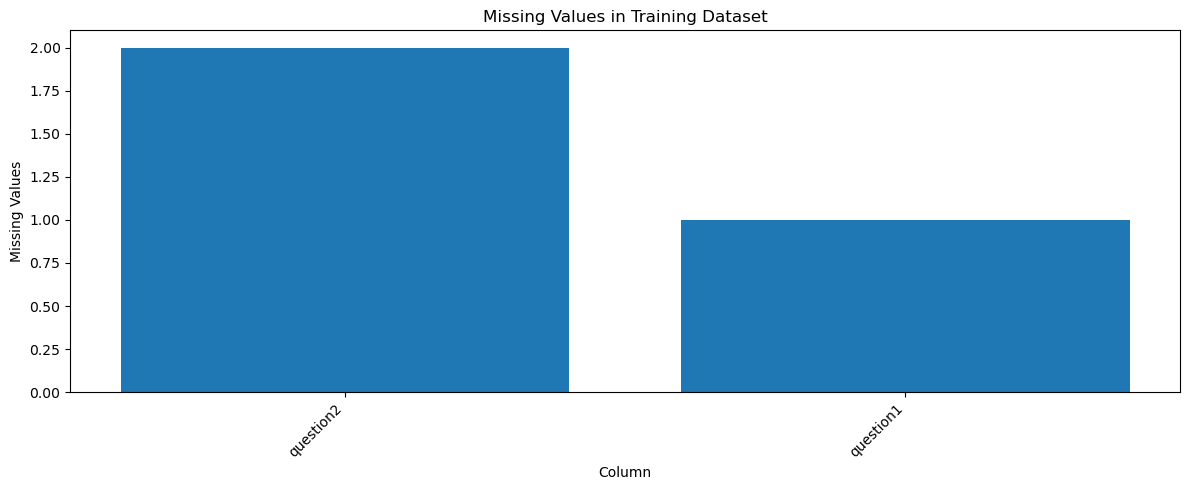

In [37]:
# ============================================================
# CELL 12: MISSING VALUE VISUALIZATION
# ============================================================

missing_plot = missing_report[
    missing_report["missing_count"] > 0
]

if missing_plot.empty:

    print("✓ No missing values found.")

else:

    plt.figure(figsize=(12, 5))

    plt.bar(
        missing_plot.index.astype(str),
        missing_plot["missing_count"]
    )

    plt.xlabel("Column")
    plt.ylabel("Missing Values")
    plt.title("Missing Values in Training Dataset")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

In [39]:
# ============================================================
# CELL 13: TARGET DISTRIBUTION
# ============================================================

TARGET = "is_duplicate"

print("Target column:", TARGET)

print("\nTarget values:")
display(
    df_raw[TARGET]
    .value_counts(
        dropna=False
    )
)

print("\nTarget percentages:")
display(
    (
        df_raw[TARGET]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
        .rename("percentage")
    )
)

Target column: is_duplicate

Target values:


is_duplicate
0    255027
1    149263
Name: count, dtype: int64


Target percentages:


is_duplicate
0    63.08
1    36.92
Name: percentage, dtype: float64

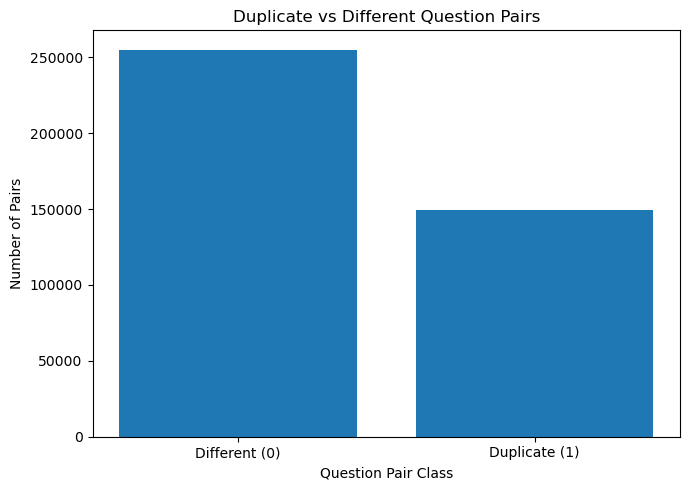

In [40]:
# ============================================================
# CELL 14: TARGET VISUALIZATION
# ============================================================

target_counts = (
    df_raw[TARGET]
    .value_counts()
    .sort_index()
)

labels = [
    "Different (0)",
    "Duplicate (1)"
]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    target_counts.values
)

plt.xlabel("Question Pair Class")
plt.ylabel("Number of Pairs")
plt.title("Duplicate vs Different Question Pairs")

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# CELL 15: CLASS BALANCE
# ============================================================

class_balance = (
    df_raw[TARGET]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
)

different_pct = class_balance.get(0, 0)
duplicate_pct = class_balance.get(1, 0)

print(
    f"Different questions : {different_pct:.2f}%"
)

print(
    f"Duplicate questions : {duplicate_pct:.2f}%"
)

difference = abs(
    different_pct - duplicate_pct
)

print(
    f"\nClass percentage difference: {difference:.2f}%"
)

Different questions : 63.08%
Duplicate questions : 36.92%

Class percentage difference: 26.16%


In [42]:
# ============================================================
# CELL 16: EMPTY QUESTIONS
# ============================================================

empty_q1 = (
    df_raw["question1"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

empty_q2 = (
    df_raw["question2"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

print(
    "Empty Question 1:",
    empty_q1.sum()
)

print(
    "Empty Question 2:",
    empty_q2.sum()
)

Empty Question 1: 1
Empty Question 2: 2


In [43]:
# ============================================================
# CELL 17: CHARACTER LENGTH STATISTICS
# ============================================================

q1_chars = (
    df_raw["question1"]
    .fillna("")
    .astype(str)
    .str.len()
)

q2_chars = (
    df_raw["question2"]
    .fillna("")
    .astype(str)
    .str.len()
)

print("Question 1 character statistics:")
display(q1_chars.describe())

print("\nQuestion 2 character statistics:")
display(q2_chars.describe())

Question 1 character statistics:


count    404290.000000
mean         59.536709
std          29.940655
min           0.000000
25%          39.000000
50%          52.000000
75%          72.000000
max         623.000000
Name: question1, dtype: float64


Question 2 character statistics:


count    404290.000000
mean         60.108365
std          33.863870
min           0.000000
25%          39.000000
50%          51.000000
75%          72.000000
max        1169.000000
Name: question2, dtype: float64

In [44]:
# ============================================================
# CELL 18: WORD COUNT STATISTICS
# ============================================================

q1_words = (
    df_raw["question1"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

q2_words = (
    df_raw["question2"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

print("Question 1 word statistics:")
display(q1_words.describe())

print("\nQuestion 2 word statistics:")
display(q2_words.describe())

Question 1 word statistics:


count    404290.000000
mean         10.942207
std           5.428828
min           0.000000
25%           7.000000
50%          10.000000
75%          13.000000
max         125.000000
Name: question1, dtype: float64


Question 2 word statistics:


count    404290.000000
mean         11.181986
std           6.305254
min           0.000000
25%           7.000000
50%          10.000000
75%          13.000000
max         237.000000
Name: question2, dtype: float64

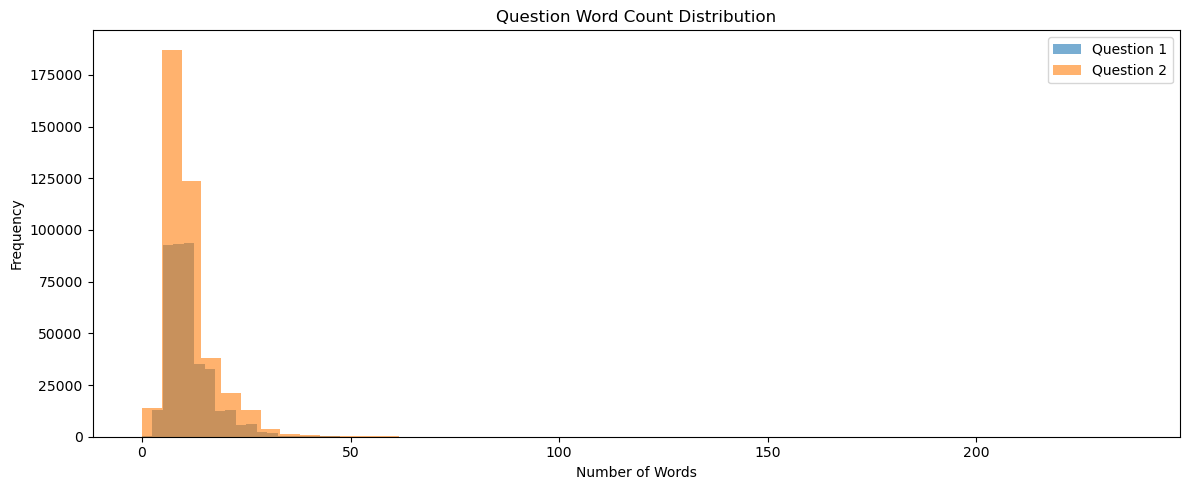

In [45]:
# ============================================================
# CELL 19: QUESTION LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 5))

plt.hist(
    q1_words,
    bins=50,
    alpha=0.6,
    label="Question 1"
)

plt.hist(
    q2_words,
    bins=50,
    alpha=0.6,
    label="Question 2"
)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Question Word Count Distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# CELL 20: EXACT DUPLICATE ROWS
# ============================================================

duplicate_rows = (
    df_raw
    .duplicated()
    .sum()
)

print(
    f"Exact duplicate rows: {duplicate_rows:,}"
)

print(
    f"Percentage: "
    f"{duplicate_rows / len(df_raw) * 100:.2f}%"
)

Exact duplicate rows: 0
Percentage: 0.00%


In [47]:
# ============================================================
# CELL 21: DUPLICATE QUESTION PAIRS
# ============================================================

exact_pairs = (
    df_raw
    .duplicated(
        subset=[
            "question1",
            "question2"
        ]
    )
    .sum()
)

reverse_pairs = (
    df_raw
    .duplicated(
        subset=[
            "question2",
            "question1"
        ]
    )
    .sum()
)

print(
    "Repeated Q1 → Q2 pairs:",
    exact_pairs
)

print(
    "Repeated reversed pairs:",
    reverse_pairs
)

Repeated Q1 → Q2 pairs: 0
Repeated reversed pairs: 0


In [48]:
# ============================================================
# CELL 22: CONFLICTING LABEL ANALYSIS
# ============================================================

pair_label_variation = (
    df_raw
    .groupby(
        [
            "question1",
            "question2"
        ]
    )[TARGET]
    .nunique()
)

conflicting_pairs = (
    pair_label_variation[
        pair_label_variation > 1
    ]
)

print(
    "Pairs with conflicting labels:",
    len(conflicting_pairs)
)

Pairs with conflicting labels: 0


In [49]:
# ============================================================
# CELL 23: CONFLICTING PAIR EXAMPLES
# ============================================================

if len(conflicting_pairs) == 0:

    print(
        "✓ No conflicting labels found "
        "for exact Q1-Q2 pairs."
    )

else:

    conflict_index = (
        conflicting_pairs.index
    )

    conflict_examples = (
        df_raw
        .set_index(
            [
                "question1",
                "question2"
            ]
        )
        .loc[conflict_index]
        .reset_index()
    )

    display(
        conflict_examples.head(20)
    )

✓ No conflicting labels found for exact Q1-Q2 pairs.


In [50]:
# ============================================================
# CELL 24: UNIQUE QUESTION ANALYSIS
# ============================================================

unique_q1 = (
    df_raw["question1"]
    .nunique(
        dropna=False
    )
)

unique_q2 = (
    df_raw["question2"]
    .nunique(
        dropna=False
    )
)

all_questions = pd.concat(
    [
        df_raw["question1"],
        df_raw["question2"]
    ],
    ignore_index=True
)

unique_questions = (
    all_questions
    .nunique(
        dropna=False
    )
)

print(
    f"Unique Question 1 values : {unique_q1:,}"
)

print(
    f"Unique Question 2 values : {unique_q2:,}"
)

print(
    f"Unique questions overall  : {unique_questions:,}"
)

Unique Question 1 values : 290,457
Unique Question 2 values : 299,175
Unique questions overall  : 537,361


In [51]:
# ============================================================
# CELL 25: MOST REPEATED QUESTIONS
# ============================================================

question_frequency = (
    all_questions
    .value_counts()
    .head(20)
)

display(
    question_frequency
    .to_frame(
        name="frequency"
    )
)

,frequency
What are the best ways to lose weight?,161
How can you look at someone's private Instagram account without following them?,120
How can I lose weight quickly?,111
What's the easiest way to make money online?,88
Can you see who views your Instagram?,79
What are some things new employees should know going into their first day at AT&T?,77
What do you think of the decision by the Indian Government to demonetize 500 and 1000 rupee notes?,68
Which is the best digital marketing course?,66
How can you increase your height?,63
How do l see who viewed my videos on Instagram?,61


In [52]:
# ============================================================
# CELL 26: QUESTION ID ANALYSIS
# ============================================================

if {
    "qid1",
    "qid2"
}.issubset(df_raw.columns):

    print("✓ qid1 and qid2 found.")

    print(
        "Unique qid1:",
        df_raw["qid1"].nunique()
    )

    print(
        "Unique qid2:",
        df_raw["qid2"].nunique()
    )

else:

    print(
        "qid1 and qid2 are not available."
    )

✓ qid1 and qid2 found.
Unique qid1: 290654
Unique qid2: 299364


In [53]:
# ============================================================
# CELL 27: REPEATED QUESTION IDS
# ============================================================

if {
    "qid1",
    "qid2"
}.issubset(df_raw.columns):

    all_qids = pd.concat(
        [
            df_raw["qid1"],
            df_raw["qid2"]
        ],
        ignore_index=True
    )

    qid_frequency = (
        all_qids
        .value_counts()
    )

    print(
        "QID frequency statistics:"
    )

    display(
        qid_frequency.describe()
    )

else:

    print(
        "Skipping QID frequency analysis."
    )

QID frequency statistics:


count    537933.000000
mean          1.503124
std           1.906517
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         157.000000
Name: count, dtype: float64

In [54]:
# ============================================================
# CELL 28: DUPLICATE QUESTION EXAMPLES
# ============================================================

duplicate_examples = df_raw[
    df_raw[TARGET] == 1
][
    [
        "question1",
        "question2",
        TARGET
    ]
]

display(
    duplicate_examples.sample(
        min(
            15,
            len(duplicate_examples)
        ),
        random_state=42
    )
)

,question1,question2,is_duplicate
95846,Should I sell an iPhone 6s and buy an iPhone SE?,Should I buy the iPhone 6s or an SE?,1
71793,What happened to the famous people who believe...,What happened to people who sold off all their...,1
51542,What are some of the top paying career options...,What is the best field for earning money after...,1
212804,How can I use my time productively during slow...,What can I do on a boring day at work?,1
373008,What is the revenue model for blogging?,What could be the revenue model for a blogging...,1
274017,Does intuition really work?,Does intuition work out?,1
353214,Can energy be borrowed from vacuum(to be retur...,Do virtual particles and energy in vacuum real...,1
364863,Why does the Quora app need access to my conta...,Why does Quora need my Google contacts?,1
42239,How many hours a day do Harvard students sleep...,Do Harvard undergraduates really have no time ...,1
388983,What are some good books on Signal and Systems?,What are the best Books for Signals And Systems?,1


In [55]:
# ============================================================
# CELL 29: DIFFERENT QUESTION EXAMPLES
# ============================================================

different_examples = df_raw[
    df_raw[TARGET] == 0
][
    [
        "question1",
        "question2",
        TARGET
    ]
]

display(
    different_examples.sample(
        min(
            15,
            len(different_examples)
        ),
        random_state=42
    )
)

,question1,question2,is_duplicate
362768,Do I legally have to let my employer know that...,Should I take a top-up home loan for doing up ...,0
172363,How do I jailbreak iOS 9.3.4?,How do I jailbreak iOS 9.2.1?,0
216382,Is my US income taxable if I am working on OPT...,I am working for company X. My client is Y (US...,0
303171,Why hasn't Ivanka Trump condemned the bigotry ...,How does it feel to date Ivanka Trump?,0
122527,Can a mortar shell be fired accurately without...,Why is my ex doing this?,0
358749,Is it really possible to increase penis size a...,Can the penis size (length or girth) be perman...,0
102476,What is the algorithm used to reserve ticket i...,"What is the meaning of PQWL, RLWL, GNWL, RLGN,...",0
16452,HELP ASAP! Not able to login to Quora! What to...,Beach ave elmwood?,0
259783,What are requirements to become Indian para co...,What is a comparison of the Indian army comman...,0
163800,Which side of the ear being pierced means bein...,What do different ear piercings mean?,0


In [56]:
# ============================================================
# CELL 30: TRAIN VS KAGGLE TEST STRUCTURE
# ============================================================

print("TRAIN DATA")
print("-" * 50)

print(
    "Rows:",
    f"{len(df_raw):,}"
)

print(
    "Columns:",
    list(df_raw.columns)
)

print()

print("KAGGLE TEST DATA")
print("-" * 50)

print(
    "Rows:",
    f"{len(df_kaggle_test):,}"
)

print(
    "Columns:",
    list(df_kaggle_test.columns)
)

TRAIN DATA
--------------------------------------------------
Rows: 404,290
Columns: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']

KAGGLE TEST DATA
--------------------------------------------------
Rows: 3,563,475
Columns: ['test_id', 'question1', 'question2']


In [57]:
# ============================================================
# CELL 31: TRAIN / TEST QUESTION OVERLAP
# ============================================================

train_questions = set(
    all_questions.dropna()
    .astype(str)
)

test_questions = set(
    pd.concat(
        [
            df_kaggle_test["question1"],
            df_kaggle_test["question2"]
        ],
        ignore_index=True
    )
    .dropna()
    .astype(str)
)

overlap = (
    train_questions &
    test_questions
)

print(
    "Unique questions in training:",
    f"{len(train_questions):,}"
)

print(
    "Unique questions in Kaggle test:",
    f"{len(test_questions):,}"
)

print(
    "Questions appearing in both:",
    f"{len(overlap):,}"
)

print(
    "Test-question overlap percentage:",
    f"{len(overlap) / max(len(test_questions), 1) * 100:.2f}%"
)

Unique questions in training: 537,360
Unique questions in Kaggle test: 4,363,831
Questions appearing in both: 112,161
Test-question overlap percentage: 2.57%


In [58]:
# ============================================================
# CELL 32: VERY SHORT QUESTIONS
# ============================================================

short_q1 = (
    df_raw["question1"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.len()
    < 5
)

short_q2 = (
    df_raw["question2"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.len()
    < 5
)

print(
    "Question 1 < 5 characters:",
    short_q1.sum()
)

print(
    "Question 2 < 5 characters:",
    short_q2.sum()
)

Question 1 < 5 characters: 44
Question 2 < 5 characters: 15


In [59]:
# ============================================================
# CELL 33: LONG QUESTION ANALYSIS
# ============================================================

long_q1 = (
    q1_chars > 300
)

long_q2 = (
    q2_chars > 300
)

print(
    "Question 1 > 300 characters:",
    long_q1.sum()
)

print(
    "Question 2 > 300 characters:",
    long_q2.sum()
)

Question 1 > 300 characters: 42
Question 2 > 300 characters: 183


In [60]:
# ============================================================
# CELL 34: FINAL EDA SUMMARY
# ============================================================

eda_summary = {
    "training_rows": len(df_raw),

    "training_columns": len(
        df_raw.columns
    ),

    "missing_cells": int(
        df_raw.isnull().sum().sum()
    ),

    "exact_duplicate_rows": int(
        duplicate_rows
    ),

    "repeated_question_pairs": int(
        exact_pairs
    ),

    "conflicting_pairs": int(
        len(conflicting_pairs)
    ),

    "unique_questions": int(
        unique_questions
    ),

    "empty_question1": int(
        empty_q1.sum()
    ),

    "empty_question2": int(
        empty_q2.sum()
    ),

    "duplicate_percentage": round(
        df_raw[TARGET].mean() * 100,
        2
    ),

    "different_percentage": round(
        (1 - df_raw[TARGET].mean()) * 100,
        2
    )
}

eda_summary_df = pd.DataFrame(
    eda_summary.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

display(
    eda_summary_df
)

,Metric,Value
0,training_rows,404290.00
1,training_columns,6.00
2,missing_cells,3.00
3,exact_duplicate_rows,0.00
4,repeated_question_pairs,0.00
5,conflicting_pairs,0.00
6,unique_questions,537361.00
7,empty_question1,1.00
8,empty_question2,2.00
9,duplicate_percentage,36.92


In [61]:
# ============================================================
# CELL 35: EDA CONCLUSION
# ============================================================

print("=" * 75)
print("QUESTION SIMILARITY PROJECT - EDA CONCLUSION")
print("=" * 75)

print()

print(
    f"Training samples        : {len(df_raw):,}"
)

print(
    f"Duplicate pairs         : "
    f"{df_raw[TARGET].mean() * 100:.2f}%"
)

print(
    f"Different pairs         : "
    f"{(1 - df_raw[TARGET].mean()) * 100:.2f}%"
)

print(
    f"Missing cells           : "
    f"{df_raw.isnull().sum().sum():,}"
)

print(
    f"Exact duplicate rows    : "
    f"{duplicate_rows:,}"
)

print(
    f"Conflicting pairs       : "
    f"{len(conflicting_pairs):,}"
)

print(
    f"Unique questions        : "
    f"{unique_questions:,}"
)

print()
print("EDA completed.")
print()
print(
    "No preprocessing was performed."
)

print(
    "No feature engineering was performed."
)

print(
    "No model training was performed."
)

print(
    "No model artifacts were created."
)

QUESTION SIMILARITY PROJECT - EDA CONCLUSION

Training samples        : 404,290
Duplicate pairs         : 36.92%
Different pairs         : 63.08%
Missing cells           : 3
Exact duplicate rows    : 0
Conflicting pairs       : 0
Unique questions        : 537,361

EDA completed.

No preprocessing was performed.
No feature engineering was performed.
No model training was performed.
No model artifacts were created.
